# Recomendaciones basadas en KNN para optimización de trabajos en HPC (Clúster Kabré de CeNAT/CONARE Costa Rica)

## Introducción


### 👥 Integrantes del grupo

|  Nombre | Carné |
|---|---|
| Daniel Garbanzo | 2022117129 |
| Luis Carlos Navarro Todd| 2022212158 |
| Ricardo Shum Estrada | 2017144193 |


A continuación se presenta el trabajo de un sistema de recomendaciones basado en KNN para optimización de trabajos Slurm en sistemas de computación de alto rendimiento (HPC), específicamente para el clúster Kabré de CeNAT/CONARE Costa Rica. El primer objetivo del trabajo es calificar los trabajos del [dataset de trabajos de Kabré](https://raw.githubusercontent.com/DylanBC09/Project-1-CeNAT/refs/heads/main/dataset.csv) en completados y no completados, para después recomendar configuraciones de recursos (partición, QOS, tiempo, memoria_reservada) para nuevos trabajos basados en trabajos anteriores similares con el objetivo de que sean completados.

Se trabajará con la metodología CRISP-DM, que consta de las siguientes fases:
| Fase | Actividad en este trabajo |
|---|---|
| **1. Business Understanding** | Descripción del problema · Pregunta analítica · Criterio de éxito medible · Justificación del algoritmo |
| **2. Data Understanding** | Carga del dataset (URL pública) · Shape, tipos, estadísticos · ≥2 gráficas · Análisis de NaN y outliers |
| **3. Data Preparation** | Limpieza · Manejo de faltantes · Normalización o estandarización · Creación de X y y|
| **4. Modeling** | Implementación desde cero del algoritmo · Verificaciones numéricas intermedias · 4 conceptos del curso con comentarios |
| **5. Evaluation** | Cross-validation del hiperparámetro · Métricas calculadas manualmente · Comparación con baseline · Análisis de error · Visualización |
| **6. Deployment** | Interpretación en contexto del dataset · Limitaciones del modelo · Respuesta a la pregunta analítica |

---




## 1. Business Understanding

### Contexto

  Los clústeres de cómputo de alto rendimiento (HPC, *High Performance Computing*)
  son infraestructuras compartidas donde múltiples usuarios envían trabajos de cómputo intensivo. El gestor de colas **Slurm** (*Simple Linux Utility for Resource Management*) recibe estas solicitudes y las planifica según los recursos disponibles: CPUs, memoria, nodos y tiempo de ejecución.

  Cada trabajo enviado compite con otros por recursos limitados. El resultado final
  puedes ser:

  | Estado | Significado |
  |--------|-------------|
  | `COMPLETED` | El trabajo terminó exitosamente |
  | `FAILED` | El trabajo falló durante la ejecución |
  | `TIMEOUT` | El trabajo excedió su límite de tiempo configurado |
  | `CANCELLED` | El trabajo fue cancelado por el usuario o el sistema |

  ### El problema

  El dataset analizado corresponde a **46,744 trabajos** ejecutados en el clúster **Kabre** del Centro Nacional de Alta Tecnología (CeNAT) de Costa Rica durante 2024, distribuidos en particiones como `andalan`, `dribe`, `kura` y `nukwa`, entre otras.

  La distribución de resultados revela un problema significativo:

  | Estado | Trabajos | Porcentaje |
  |--------|----------|------------|
  | `FAILED` | 24,335 | 52.1% |
  | `COMPLETED` | 16,782 | 35.9% |
  | `CANCELLED` | 4,001 | 8.6% |
  | `TIMEOUT` | 1,621 | 3.5% |

  **Solo el 35.9% de los trabajos se completan exitosamente.** Esto representa un
  costo
  significativo: tiempo de investigador desperdiciado, recursos computacionales
  consumidos
  sin resultado, y retrasos en proyectos científicos.

  ### Objetivo

  Este proyecto aborda el problema en dos etapas:

  1. **Predicción**: Predecir si un trabajo (*CPUs solicitados, memoria, partición, límite de tiempo, prioridad,
     momento de envío*) será completado exitosamente (`COMPLETED`) o
  no.

  2. **Recomendación**: Para los trabajos predichos como no exitosos, generar
     **contrafactuales** — sugerencias concretas y accionables sobre cómo modificar
     la configuración del trabajo para aumentar su probabilidad de éxito.

  ### Pregunta analítica

*"¿Es posible predecir con precisión si un trabajo en el clúster Kabré se completará exitosamente, y si no, qué cambios específicos en su configuración podrían aumentar esa probabilidad?"*

  La idea es que el sistema actue como un asistente de diagnóstico previo al envío. Por ejemplo:

  > *"Tu trabajo tiene una probabilidad del 12% de completarse. Si reduces el límite
  > de tiempo de 7 días a 2 días y cambias la partición de `nu-long` a `nukwa`, la
  > probabilidad sube al 68%."*

  Esto permite al investigador tomar decisiones informadas antes de comprometer
  recursos,
  reduciendo el ciclo de prueba y error que hoy es la norma en el uso de clústeres
  HPC.

  ### Criterio de éxito
  El éxito se medirá en dos niveles:
  1. **Predicción**: Un modelo de clasificación binaria con una precisión (accuracy) de al menos el 90% en un conjunto de prueba separado.
  2. **Recomendación**: Contrafactuales que, al ser aplicados a trabajos no exitosos, aumenten su probabilidad de éxito en al menos un 30% según el modelo predictivo. # TODO REVISAR ESTE CRITERIO

  ### Enfoque técnico

  El clasificador se implementa con **k-Nearest Neighbours (kNN) desde cero**,
  eligiendo este algoritmo por su interpretabilidad geométrica natural: la vecindad de un punto en el espacio de features define directamente cuáles trabajos similares
  fueron exitosos, lo que facilita la construcción de los contrafactuales sin
  necesidad de aproximaciones adicionales. Además, ya ha sido explorado en el contexto de Kabré.

  ---

# 2. Data Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (10, 4)
sns.set_theme(style='whitegrid', palette='muted')

# Carga del dataset (separador pipe)
df = pd.read_csv('dataset.csv', sep='|', parse_dates=['Submit'])

print(f"Shape: {df.shape}")
display(df.head())

Shape: (46744, 12)


,ConsumedEnergyRaw,CPUTimeRAW,ReqCPUS,ReqMem,ReqNodes,ResvCPURAW,Submit,TimelimitRaw,Partition,Priority,QOS,State
0,0.0,158517504,1,100Mc,1,1,2024-06-24 12:33:26,10320,nu-long,6831,normal,TIMEOUT
1,0.0,29018640,1,100Mc,1,45900,2024-06-25 01:04:00,10080,nukwa-long,7046,normal,FAILED
2,3774906.0,4147392,1,100Mc,1,432175,2024-06-25 14:03:37,1440,nukwa-wide,7046,normal,TIMEOUT
3,3723128.0,4088688,1,100Mc,1,518590,2024-06-25 14:03:56,1440,nukwa-wide,7046,normal,COMPLETED
4,12583983.0,7135296,1,100Mc,1,584164,2024-06-25 19:30:43,4320,nukwa,7058,normal,COMPLETED


In [2]:
### 2.2 Tipos de datos y estadísticos descriptivos
print("=== Tipos de datos ===")
print(df.dtypes)
print(f"\n=== Estadísticos (variables numéricas) ===")
display(df.describe())

=== Tipos de datos ===
ConsumedEnergyRaw           float64
CPUTimeRAW                    int64
ReqCPUS                       int64
ReqMem                          str
ReqNodes                      int64
ResvCPURAW                    int64
Submit               datetime64[us]
TimelimitRaw                    str
Partition                       str
Priority                      int64
QOS                             str
State                           str
dtype: object

=== Estadísticos (variables numéricas) ===


,ConsumedEnergyRaw,CPUTimeRAW,ReqCPUS,ReqNodes,ResvCPURAW,Submit,Priority
count,4.349500e+04,4.674400e+04,46744.000000,46744.000000,4.674400e+04,46744,46744.000000
mean,1.111793e+06,7.526978e+05,16.085337,1.052092,1.053280e+05,2024-11-24 18:01:25.763435,5733.606238
min,0.000000e+00,0.000000e+00,1.000000,1.000000,0.000000e+00,2024-06-24 12:33:26,1895.000000
25%,7.570000e+02,2.560000e+02,1.000000,1.000000,0.000000e+00,2024-09-23 19:31:49.750000,3664.250000
50%,9.377000e+03,2.816000e+03,12.000000,1.000000,1.000000e+00,2024-11-02 14:21:27,5014.000000
75%,7.392400e+04,1.989600e+04,24.000000,1.000000,2.400000e+01,2025-01-30 14:52:15.500000,6142.000000
max,7.849188e+08,6.856732e+08,1000.000000,18.000000,3.594862e+08,2025-04-30 23:57:36,16136.000000
std,8.445855e+06,9.765787e+06,27.276524,0.497478,3.780053e+06,NaN,3581.251987


### 2.3 Valores nulos y duplicados

In [3]:
nulls = df.isnull().sum()
nulls_pct = nulls / len(df) * 100
null_df = pd.DataFrame({'Nulos': nulls, '% Nulos': nulls_pct}).query('Nulos > 0')

if null_df.empty:
    print("No hay valores nulos en el dataset.")
else:
    display(null_df)

dups = df.duplicated().sum()
print(f"\nFilas duplicadas: {dups} ({dups/len(df)*100:.2f}%)")

,Nulos,% Nulos
ConsumedEnergyRaw,3249,6.950625



Filas duplicadas: 824 (1.76%)


### 2.4 Variable objetivo: distribución de `State`

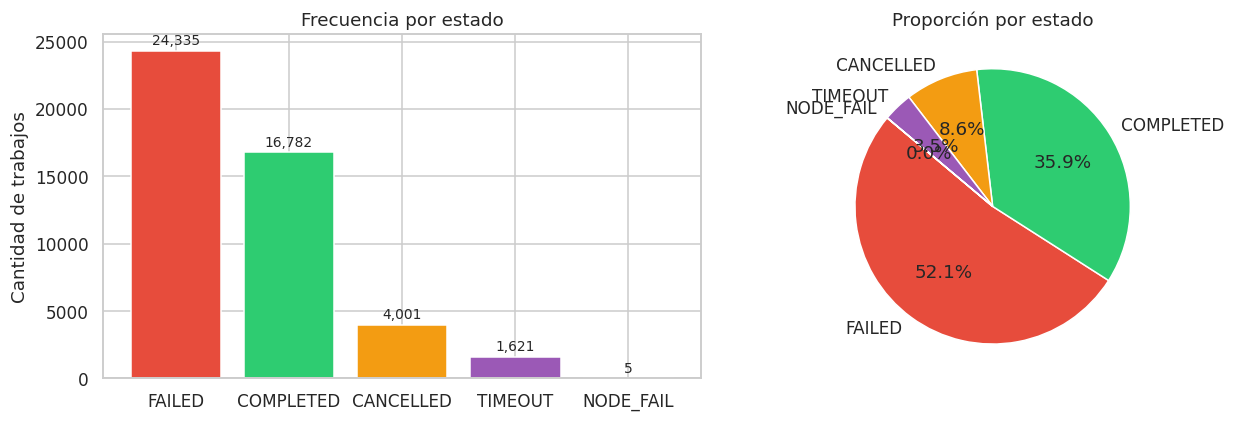


Tabla resumen:


,Trabajos,%
State,,
FAILED,24335,52.06
COMPLETED,16782,35.90
CANCELLED,4001,8.56
TIMEOUT,1621,3.47
NODE_FAIL,5,0.01


In [4]:
df['State'] = df['State'].str.split().str[0]  # Solo la primera palabra (ej. "COMPLETED" de "COMPLETED (0)")
state_counts = df['State'].value_counts()
state_pct = state_counts / len(df) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barras
colors = {'COMPLETED': '#2ecc71', 'FAILED': '#e74c3c', 'CANCELLED': '#f39c12', 'TIMEOUT': '#9b59b6'}
bar_colors = [colors.get(s, '#95a5a6') for s in state_counts.index]
axes[0].bar(state_counts.index, state_counts.values, color=bar_colors, edgecolor='white')
axes[0].set_title('Frecuencia por estado')
axes[0].set_ylabel('Cantidad de trabajos')
for bar, val in zip(axes[0].patches, state_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', va='bottom', fontsize=9)

# Pie
axes[1].pie(state_pct.values, labels=state_pct.index,
            autopct='%1.1f%%', colors=bar_colors, startangle=140)
axes[1].set_title('Proporción por estado')

plt.tight_layout()
plt.show()

print("\nTabla resumen:")
display(pd.DataFrame({'Trabajos': state_counts, '%': state_pct.round(2)}))

### 2.5 Variables categóricas: `Partition` y `QOS`

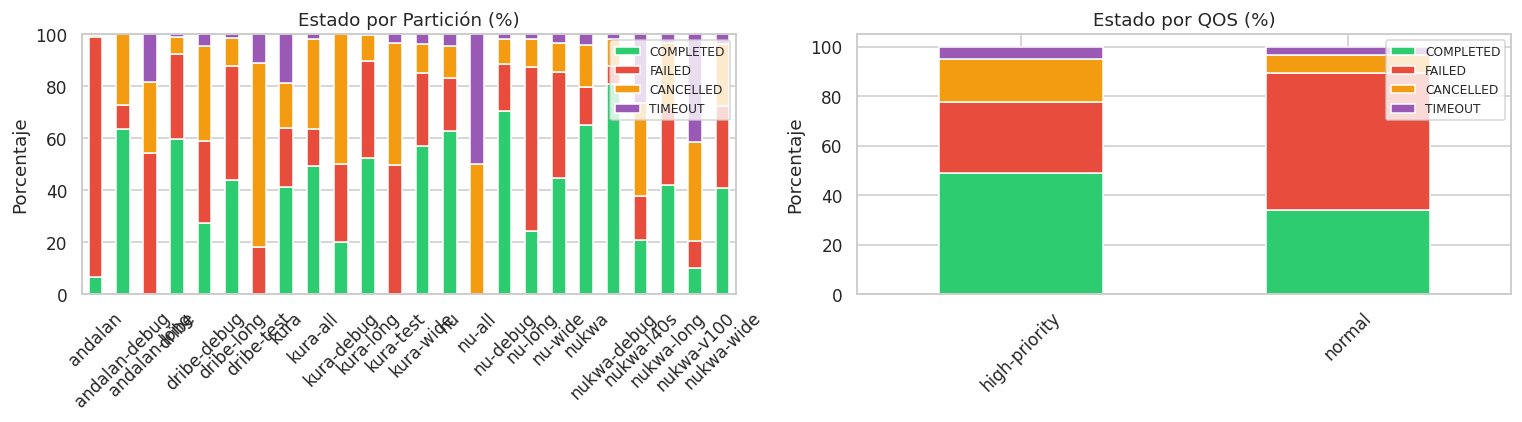

Trabajos por Partición:


,Trabajos
Partition,
andalan,16097
dribe,6554
kura,3926
nu-long,3227
nukwa,3049
nu,2682
dribe-long,2527
nu-wide,1826
kura-long,1660



Trabajos por QOS:


,Trabajos
QOS,
normal,40807
high-priority,5937


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Partición
part_state = df.groupby(['Partition', 'State']).size().unstack(fill_value=0)
part_state_pct = part_state.div(part_state.sum(axis=1), axis=0) * 100
part_state_pct[['COMPLETED', 'FAILED', 'CANCELLED', 'TIMEOUT']].plot(
    kind='bar', stacked=True, ax=axes[0],
    color=['#2ecc71', '#e74c3c', '#f39c12', '#9b59b6'])
axes[0].set_title('Estado por Partición (%)')
axes[0].set_ylabel('Porcentaje')
axes[0].set_xlabel('')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].tick_params(axis='x', rotation=45)

# QOS
qos_state = df.groupby(['QOS', 'State']).size().unstack(fill_value=0)
qos_state_pct = qos_state.div(qos_state.sum(axis=1), axis=0) * 100
qos_state_pct[['COMPLETED', 'FAILED', 'CANCELLED', 'TIMEOUT']].plot(
    kind='bar', stacked=True, ax=axes[1],
    color=['#2ecc71', '#e74c3c', '#f39c12', '#9b59b6'])
axes[1].set_title('Estado por QOS (%)')
axes[1].set_ylabel('Porcentaje')
axes[1].set_xlabel('')
axes[1].legend(loc='upper right', fontsize=8)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Trabajos por Partición:")
display(df['Partition'].value_counts().to_frame('Trabajos'))
print("\nTrabajos por QOS:")
display(df['QOS'].value_counts().to_frame('Trabajos'))

### 2.6 Variables numéricas: distribuciones y outliers

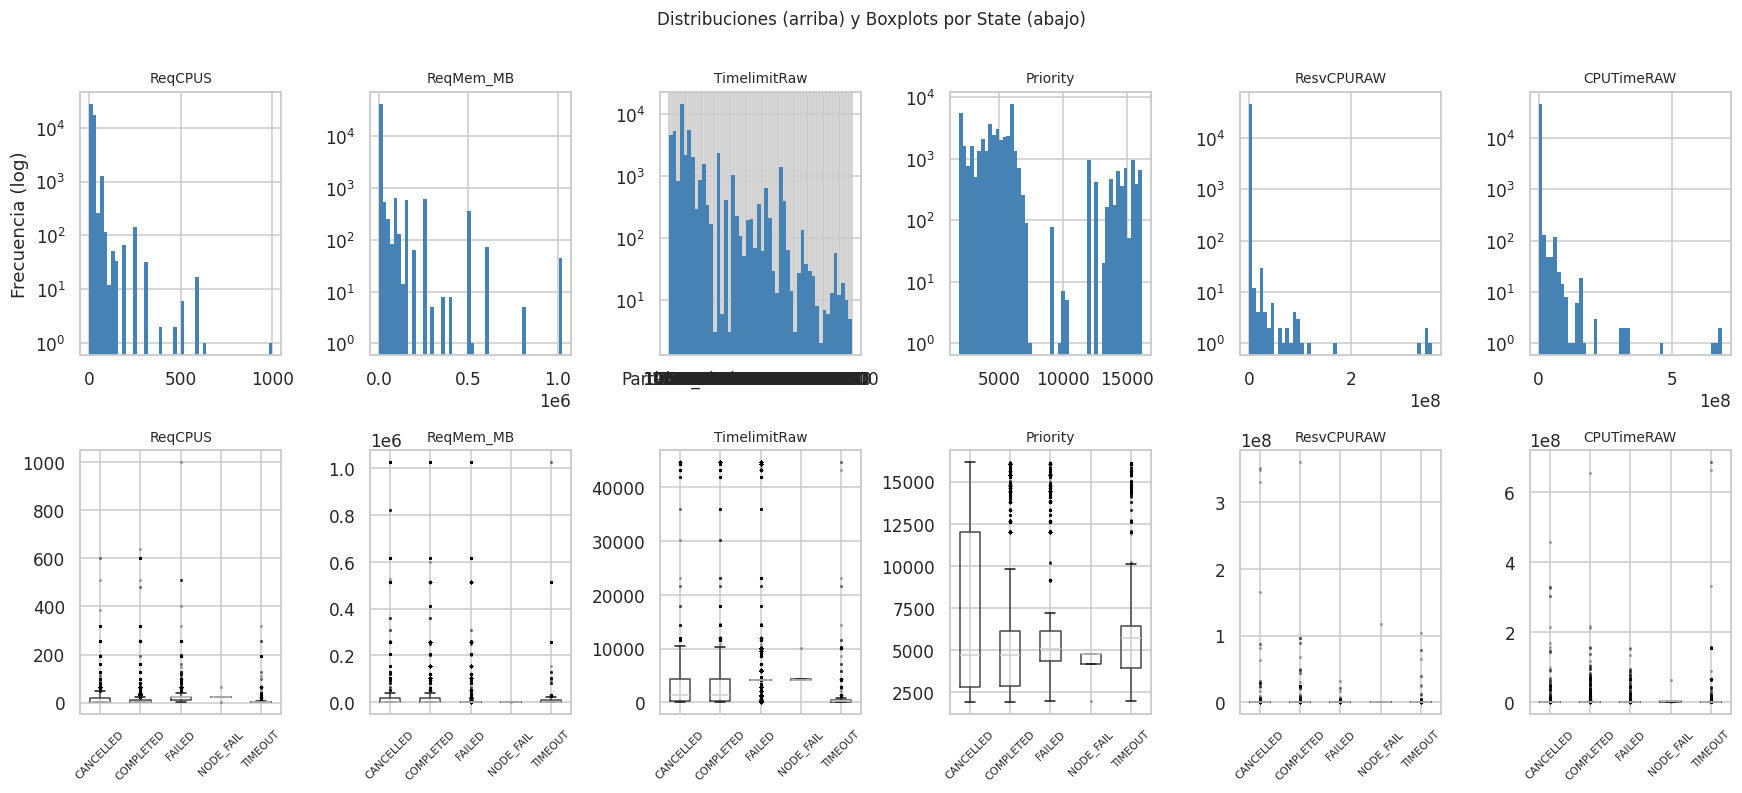

In [6]:
# Parsear ReqMem: convierte '100Mc' -> 100 MB/core, '4Gn' -> 4096 MB/nodo, etc.
def parse_reqmem(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip()
    if val.endswith('Mc'):
        return float(val[:-2])          # MB por core
    elif val.endswith('Mn'):
        return float(val[:-2])          # MB por nodo
    elif val.endswith('Gc'):
        return float(val[:-2]) * 1024   # GB por core -> MB
    elif val.endswith('Gn'):
        return float(val[:-2]) * 1024   # GB por nodo -> MB
    else:
        try:
            return float(val)
        except:
            return np.nan

df['ReqMem_MB'] = df['ReqMem'].apply(parse_reqmem)

num_cols = ['ReqCPUS', 'ReqMem_MB', 'TimelimitRaw', 'Priority', 'ResvCPURAW', 'CPUTimeRAW']

fig, axes = plt.subplots(2, len(num_cols), figsize=(16, 7))

for i, col in enumerate(num_cols):
    data = df[col].dropna()
    # Histograma (log scale)
    axes[0, i].hist(data, bins=50, color='steelblue', edgecolor='none', log=True)
    axes[0, i].set_title(col, fontsize=9)
    axes[0, i].set_xlabel('')
    axes[0, i].set_ylabel('Frecuencia (log)' if i == 0 else '')

    # Boxplot por estado
    numeric_col = pd.to_numeric(df[col], errors='coerce')
    plot_df = df.loc[numeric_col.notna(), ['State']].copy()
    plot_df[col] = numeric_col[numeric_col.notna()]
    plot_df.boxplot(column=col, by='State', ax=axes[1, i],
                    flierprops=dict(marker='.', markersize=2, alpha=0.3))
    axes[1, i].set_title(col, fontsize=9)
    axes[1, i].set_xlabel('')
    axes[1, i].tick_params(axis='x', rotation=45, labelsize=7)

plt.suptitle('')
fig.text(0.5, 1.01, 'Distribuciones (arriba) y Boxplots por State (abajo)', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

In [7]:
# Parece haber data no numérica en TimelimitRaw
print("Valores únicos en TimelimitRaw:")
display(df['TimelimitRaw'].unique())

Valores únicos en TimelimitRaw:


<StringArray>
[          '10320',           '10080',            '1440',            '4320',
            '9600',             '479',            '2640',            '5760',
            '4200', 'Partition_Limit',
 ...
             '179',           '12240',             '190',             '960',
              '80',              '15',             '840',            '3900',
            '1140',           '10800']
Length: 127, dtype: str

### 2.7 Análisis temporal: envíos por mes y hora del día

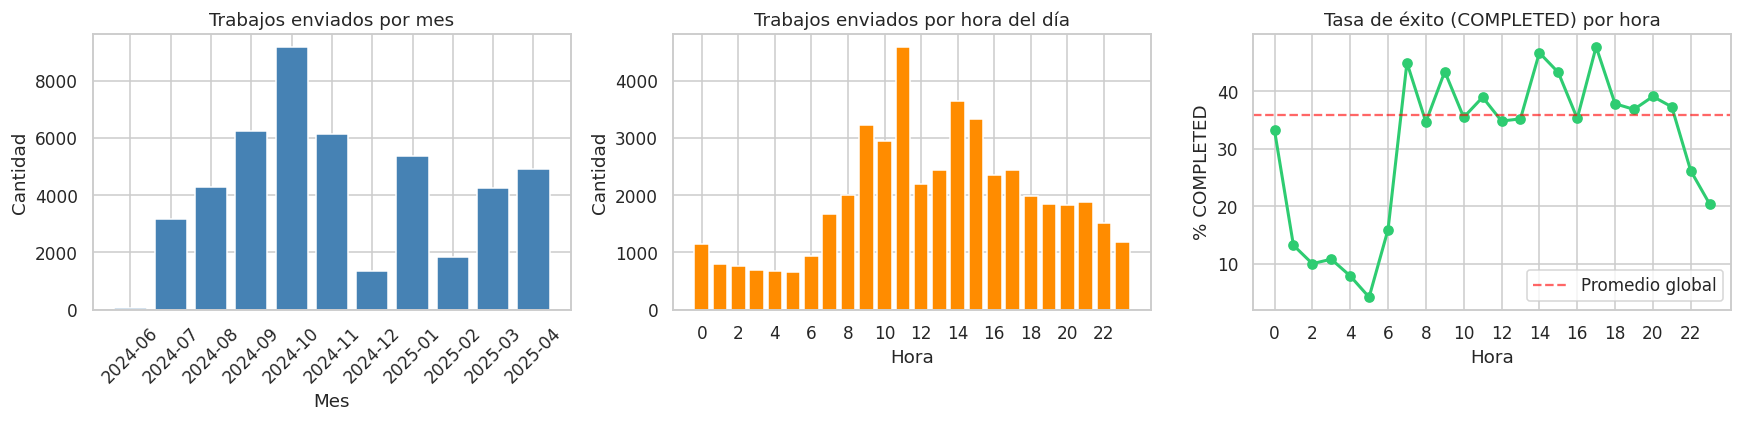

In [8]:
df['submit_month'] = df['Submit'].dt.to_period('M')
df['submit_hour'] = df['Submit'].dt.hour
df['submit_dow'] = df['Submit'].dt.day_name()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Trabajos por mes
month_counts = df.groupby('submit_month').size()
axes[0].bar(month_counts.index.astype(str), month_counts.values, color='steelblue')
axes[0].set_title('Trabajos enviados por mes')
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=45)

# Trabajos por hora del día
hour_counts = df.groupby('submit_hour').size()
axes[1].bar(hour_counts.index, hour_counts.values, color='darkorange')
axes[1].set_title('Trabajos enviados por hora del día')
axes[1].set_xlabel('Hora')
axes[1].set_ylabel('Cantidad')
axes[1].set_xticks(range(0, 24, 2))

# Tasa de completado por hora del día
completed_by_hour = df[df['State'] == 'COMPLETED'].groupby('submit_hour').size()
total_by_hour = df.groupby('submit_hour').size()
success_rate = (completed_by_hour / total_by_hour * 100).fillna(0)
axes[2].plot(success_rate.index, success_rate.values, marker='o', color='#2ecc71', linewidth=2)
axes[2].set_title('Tasa de éxito (COMPLETED) por hora')
axes[2].set_xlabel('Hora')
axes[2].set_ylabel('% COMPLETED')
axes[2].set_xticks(range(0, 24, 2))
axes[2].axhline(df['State'].eq('COMPLETED').mean() * 100, color='red',
                linestyle='--', alpha=0.6, label='Promedio global')
axes[2].legend()

plt.tight_layout()
plt.show()

### 2.8 Resumen de hallazgos del EDA

| Hallazgo | Detalle |
|---|---|
| **Desbalance de clases** | Solo el ~36% de trabajos son `COMPLETED`; el ~52% son `FAILED`. Requiere manejo de desbalance en el modelo. |
| **Partición crítica** | Las tasas de éxito varían mucho por partición — algunas tienen >60% de éxito, otras casi 0%. La partición es feature clave. Además se deberían unir por tipo (Andalán, Nukwa, Nu, Kurá ,Dribe) |
| **Tasa de éxito por hora** | Los trabajos suelen tener una tasa de éxito más alta durante ciertas horas del día. |
| **Nulos** | Algunas columnas numéricas tienen valores nulos que deben ser manejados (imputación o eliminación). |
| **TimelimitRaw con valores no numéricos** | Aparecen valores no numéricos en la columna `TimelimitRaw` que deben ser tratados. |

# 3. Data Preparation

### 3.1 Limpieza de datos

#### 3.1.1 Nulos y Duplicados


In [9]:
# Remover nulos y duplicados
print(f"Shape original: {df.shape}")
print(f"Nulos totales originales: {df.isnull().sum().sum()}")
print(f"Duplicados originales: {df.duplicated().sum()}")

df = df.dropna().drop_duplicates().reset_index(drop=True)

print("\nDespués de limpieza:")
print(f"Shape: {df.shape}")
print(f"Nulos totales: {df.isnull().sum().sum()}")
print(f"Duplicados: {df.duplicated().sum()}")

Shape original: (46744, 16)
Nulos totales originales: 3249
Duplicados originales: 824

Después de limpieza:
Shape: (42745, 16)
Nulos totales: 0
Duplicados: 0


#### 3.1.2 Particiones Estandarizadas

Se unirán las particiones por tipo para reducir la cardinalidad y mejorar la generalización del modelo. Por ejemplo, `andalan`, `andalan-long` y `andalan-debug` se agruparán como `Andalán`. Esto también ayuda a mitigar el problema de particiones con muy pocos ejemplos.

In [10]:
df['PartitionGroup'] = df['Partition'].str.split('-').str[0].str.capitalize()  # Unificar por tipo (Andalán, Nukwa, Nu, Kurá ,Dribe)
print("Particiones estandarizadas:")
display(df['PartitionGroup'].value_counts().to_frame('Trabajos'))

Particiones estandarizadas:


,Trabajos
PartitionGroup,
Andalan,15596
Nu,8506
Dribe,8485
Nukwa,5171
Kura,4987


#### 3.1.3 Manejo de valores no numéricos en `TimelimitRaw`

In [11]:
# Parsear TimelimitRaw según partición:
# - Si es numérico, se conserva.
# - Si viene como "Partition_Limit" (u otro no numérico), se reemplaza por esto:
# nukwa	GPU	1	24 horas
# nukwa-debug	GPU	1	4 horas
# nukwa-wide	GPU	2	24 horas
# nukwa-long	GPU	1	48 horas
# dribe-long	Xeon	1	744 horas
# dribe	Xeon	1	72 horas
# dribe-debug	Xeon	1	8 horas
# kurá-debug	Xeon	1	8 horas
# kurá-wide	Xeon	4	24 horas
# kurá	Xeon	1	72 horas
# kurá-long	Xeon	1	168 horas
# Andalan y Nu igual que Kurá
def parse_timelimit(val, partition):
    if pd.isna(val):
        return np.nan
    val = str(val).strip()
    if val.isdigit():
        return float(val)
    mapping = {
        'nukwa': 24 * 3600,
        'nukwa-debug': 4 * 3600,
        'nukwa-wide': 24 * 3600,
        'nukwa-long': 48 * 3600,
        'dribe-long': 744 * 3600,
        'dribe': 72 * 3600,
        'dribe-debug': 8 * 3600,
        'kurá-debug': 8 * 3600,
        'kurá-wide': 24 * 3600,
        'kurá': 72 * 3600,
        'kurá-long': 168 * 3600,
        'andalan': 72 * 3600,
        'andalan-debug': 8 * 3600,
        'andalan-long': 168 * 3600,
        'nu': 72 * 3600,
        'nu-debug': 8 * 3600,
        'nu-long': 168 * 3600
    }
    for key in mapping:
        if key in partition.lower():
            return mapping[key]
    return np.nan
df['TimelimitSec'] = df.apply(lambda row: parse_timelimit(row['TimelimitRaw'], row['Partition']), axis=1)
print("TimelimitRaw parseado:")
display(df[['TimelimitRaw', 'Partition', 'TimelimitSec']].head(10))

TimelimitRaw parseado:


,TimelimitRaw,Partition,TimelimitSec
0,10320,nu-long,10320.0
1,10080,nukwa-long,10080.0
2,1440,nukwa-wide,1440.0
3,1440,nukwa-wide,1440.0
4,4320,nukwa,4320.0
5,1440,nukwa-wide,1440.0
6,1440,nukwa-wide,1440.0
7,9600,nu-wide,9600.0
8,9600,nu-wide,9600.0
9,9600,nu-wide,9600.0


### 3.2 Correlaciones entre variables numéricas

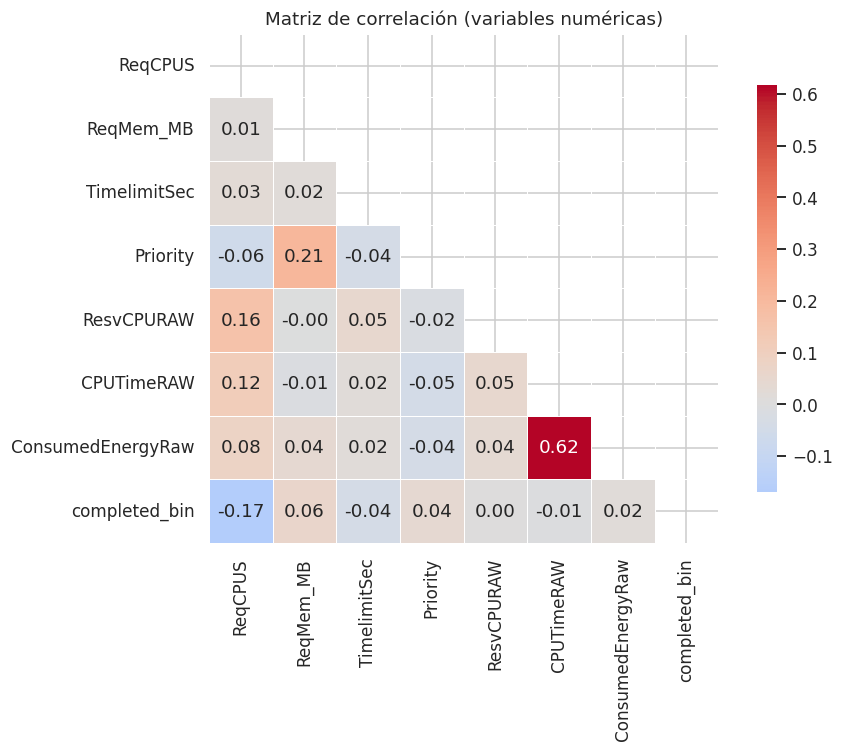


Correlación con 'completed_bin':


ReqCPUS             -0.169597
ReqMem_MB            0.061472
Priority             0.045000
TimelimitSec        -0.037622
ConsumedEnergyRaw    0.016790
CPUTimeRAW          -0.006586
ResvCPURAW           0.000595
Name: completed_bin, dtype: float64

In [12]:
# Variable objetivo binaria para correlación
df['completed_bin'] = (df['State'] == 'COMPLETED').astype(int)

corr_cols = ['ReqCPUS', 'ReqMem_MB', 'TimelimitSec', 'Priority',
             'ResvCPURAW', 'CPUTimeRAW', 'ConsumedEnergyRaw', 'completed_bin']

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Matriz de correlación (variables numéricas)')
plt.tight_layout()
plt.show()

# Correlaciones con el target ordenadas
print("\nCorrelación con 'completed_bin':")
display(corr_matrix['completed_bin'].drop('completed_bin').sort_values(key=abs, ascending=False))

### 3.3 Análisis de outliers con IQR

In [13]:
outlier_cols = ['ReqCPUS', 'ReqMem_MB', 'TimelimitSec', 'Priority', 'CPUTimeRAW']

rows = []
for col in outlier_cols:
    data = df[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    lb, ub = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    lb = max(lb, 0)  # No permitir límites negativos
    n_out = ((data < lb) | (data > ub)).sum()
    rows.append({'Columna': col, 'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                 'Límite inferior': lb, 'Límite superior': ub,
                 'Outliers': n_out, '% Outliers': round(n_out / len(data) * 100, 2)})

outlier_df = pd.DataFrame(rows).set_index('Columna')
display(outlier_df)

plt.tight_layout()
plt.show()

,Q1,Q3,IQR,Límite inferior,Límite superior,Outliers,% Outliers
Columna,,,,,,,
ReqCPUS,1.0,24.0,23.0,0,58.5,1869,4.37
ReqMem_MB,100.0,2000.0,1900.0,0,4850.0,9947,23.27
TimelimitSec,600.0,4200.0,3600.0,0,9600.0,3472,8.12
Priority,3670.0,6142.0,2472.0,0,9850.0,5030,11.77
CPUTimeRAW,256.0,19560.0,19304.0,0,48516.0,7085,16.58


<Figure size 1100x440 with 0 Axes>

Se pueden observar varios outliers, sin embargo, son datos que se encuentran dentro de lo esperado para un clúster HPC, por lo que se mantendrán para preservar la variabilidad real del dataset. 

### 3.4 One-hot encoding de variables categóricas

In [14]:
def one_hot(value: str, categories: list[str]) -> list[float]:
    return [1.0 if value.strip() == c else 0.0 for c in categories]

### 3.5 Creación de matrices de características (X) y etiquetas (y)



In [ ]:
PARTITION_GROUPS = df['PartitionGroup'].unique().tolist()
QOS_CATEGORIES = df['QOS'].unique().tolist()

def build_features(row: dict) -> list[float] | None:
    """
    Returns a feature vector or None if the row has critical missing values.

    Feature vector layout (14 dims):
      [0]  ReqCPUS
      [1]  ReqMem_MB
      [2]  ReqNodes
      [3]  ResvCPURAW
      [4]  TimelimitSec
      [5]  Priority
      [6]  submit_hour
      [7]  submit_dow
      [8..12]  one-hot Partition  (5 categories)
      [13,14]  one-hot QOS        (2 categories)
    """
    try:
        req_cpus = float(row["ReqCPUS"])
        req_mem = float(row["ReqMem_MB"])
        req_nodes = float(row["ReqNodes"])
        resv_cpu = float(row["ResvCPURAW"])
        timelimit = float(row["TimelimitSec"])
        priority = float(row["Priority"])
        hour, dow = float(row["submit_hour"]), float(row["Submit"].dayofweek)
    except (ValueError, KeyError):
        print(f"Fila con datos faltantes o no numéricos: {row.get('JobID', 'N/A')}")
        return None

    vec = [
        req_cpus,
        req_mem,
        req_nodes,
        resv_cpu,
        timelimit,
        priority,
        float(hour),
        float(dow),
        *one_hot(row["PartitionGroup"], PARTITION_GROUPS),
        *one_hot(row["QOS"], QOS_CATEGORIES),
    ]
    return vec

In [62]:
X_raw, y_raw = [], df['State'].apply(lambda s: 1 if s.strip() == 'COMPLETED' else 0).tolist()

for _, row in df.iterrows():
    features = build_features(row)
    if features is not None:
        X_raw.append(features)

print(f"Total muestras con features: {len(X_raw)}")

Total muestras con features: 42745


### 3.6 División del Dataset

In [63]:
def split_list(lst, test_ratio: float = 0.2) -> tuple:
    cut = int(len(lst) * test_ratio)
    return lst[cut:], lst[:cut]   # train, test


def stratified_split(
    X: list[list[float]],
    y: list[int],
    test_ratio: float = 0.2,
    seed: int = 42,
) -> tuple:
    """Returns X_train, X_test, y_train, y_test."""
    import random
    rng = random.Random(seed)

    idx_pos = [i for i, label in enumerate(y) if label == 1]
    idx_neg = [i for i, label in enumerate(y) if label == 0]

    rng.shuffle(idx_pos)
    rng.shuffle(idx_neg)

    train_pos, test_pos = split_list(idx_pos, test_ratio)
    train_neg, test_neg = split_list(idx_neg, test_ratio)

    train_idx = train_pos + train_neg
    test_idx = test_pos + test_neg
    rng.shuffle(train_idx)
    rng.shuffle(test_idx)

    X_train = [X[i] for i in train_idx]
    y_train = [y[i] for i in train_idx]
    X_test = [X[i] for i in test_idx]
    y_test = [y[i] for i in test_idx]

    return X_train, X_test, y_train, y_test


In [64]:
X_train, X_test, y_train, y_test = stratified_split(X_raw, y_raw, test_ratio=0.2, seed=42)

### 3.7 Normalización de Datos

In [65]:
class MinMaxScaler:
    def __init__(self):
        self.mins: list[float] = []
        self.maxs: list[float] = []

    def fit(self, X: list[list[float]]) -> "MinMaxScaler":
        n_feat = len(X[0])
        self.mins = [min(row[j] for row in X) for j in range(n_feat)]
        self.maxs = [max(row[j] for row in X) for j in range(n_feat)]
        return self

    def transform(self, X: list[list[float]]) -> list[list[float]]:
        scaled = []
        for row in X:
            new_row = []
            for j, val in enumerate(row):
                denom = self.maxs[j] - self.mins[j]
                new_row.append(
                    (val - self.mins[j]) / denom if denom > 0 else 0.0)
            scaled.append(new_row)
        return scaled

    def inverse_transform_one(self, row: list[float]) -> list[float]:
        """Recover original-scale values from a single scaled row."""
        return [
            val * (self.maxs[j] - self.mins[j]) + self.mins[j]
            for j, val in enumerate(row)
        ]

    def fit_transform(self, X: list[list[float]]) -> list[list[float]]:
        return self.fit(X).transform(X)

In [66]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)